<a href="https://colab.research.google.com/github/Migu-alt/Estructura-de-datos-y-lab/blob/main/Quad_tree_laboratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***laboratorio del quad-tree***

In [4]:
import random
import json
'''
aqui se genera la lista con los datos que se necesitan para el arbol
pero, con un formato que no esta adecuado para este, despues antes
de llamar al arbol hay que modificarlo para que quede en tuplas
'''
lista_coordenadas = []
# Generar 10,000 datos con la estructura requerida
for i in range(10000):
    x = random.randint(0, 10000)
    y = random.randint(0, 10000)
    entrega = {
        "X": x,
        "Y": y
    }
    lista_coordenadas.append(entrega)
print("coordenadas = [")
for i in range(3):
    e = lista_coordenadas[i]
    print(f'    {{"X": {e["X"]}, "Y": {e["Y"]}}},')
print("    # ... y así hasta 10,000")
print("]")

coordenadas = [
    {"X": 2964, "Y": 5097},
    {"X": 2586, "Y": 6301},
    {"X": 5628, "Y": 717},
    # ... y así hasta 10,000
]


###***construccion de el arbol***

In [35]:
import math

''' IMPORTANTE
en el quad-tree el espacio se divide en 4 regiones (cuadrantes)
en lugar de dividir por eje como en el KD-tree
cada nodo representa una región del espacio
y el codigo no esta pensado para k-dimenciones,
solo funciona en dos dimenciones
'''

# Clase para representar un nodo en el Quad-tree.
# Cada nodo almacena una región (limites), un punto opcional,
# y referencias a sus 4 hijos (cuadrantes).
class nodocoordenada:
    def __init__(self, limite, punto=None):
        self.limite = limite   # (xmin, ymin, xmax, ymax)
        self.punto = punto     # Punto almacenado en el nodo

        # Hijos (cuadrantes)
        self.NE = None
        self.NW = None
        self.SE = None
        self.SW = None

        self.dividido = False  # Indica si el nodo fue subdividido


# Clase principal del Quad-tree.
class Quad_tree:
    def __init__(self, coordenadas):
        # 'coordenadas' es lista de puntos (x,y)
        limite = self.limite(coordenadas) # 'limite' define el espacio total (xmin, ymin, xmax, ymax)
        self.raiz = self.construir(coordenadas, limite)

    # Método para construir el Quad-tree.
    def limite(self, coordenadas):
        margen = 1
        xmin = min(coord[0] for coord in coordenadas)
        ymin = min(coord[1] for coord in coordenadas)
        xmax = max(coord[0] for coord in coordenadas)
        ymax = max(coord[1] for coord in coordenadas)
        return (xmin - margen, ymin - margen, xmax + margen, ymax + margen)

    def construir(self, coordenadas, limite):
        nodo = nodocoordenada(limite)

        for punto in coordenadas:
            self.insertar(nodo, punto)

        return nodo

    # Verifica si un punto está dentro de un límite
    def en_limite(self, punto, limite):
        x, y = punto
        xmin, ymin, xmax, ymax = limite
        return xmin <= x <= xmax and ymin <= y <= ymax

    # Divide un nodo en 4 cuadrantes
    def subdividir(self, nodo):
        xmin, ymin, xmax, ymax = nodo.limite
        midx = (xmin + xmax) / 2
        midy = (ymin + ymax) / 2

        nodo.NE = nodocoordenada((midx, midy, xmax, ymax))
        nodo.NW = nodocoordenada((xmin, midy, midx, ymax))
        nodo.SE = nodocoordenada((midx, ymin, xmax, midy))
        nodo.SW = nodocoordenada((xmin, ymin, midx, midy))

        nodo.dividido = True

    # Helper para insertar un punto en el cuadrante correcto
    def _insertar_en_cuadrante_correcto(self, nodo, punto):
        xmin, ymin, xmax, ymax = nodo.limite
        midx = (xmin + xmax) / 2
        midy = (ymin + ymax) / 2
        px, py = punto

        # Determina a qué cuadrante pertenece el punto
        if px >= midx:
            if py >= midy:
                return self.insertar(nodo.NE, punto)
            else:
                return self.insertar(nodo.SE, punto)
        else:
            if py >= midy:
                return self.insertar(nodo.NW, punto)
            else:
                return self.insertar(nodo.SW, punto)

    # Inserta un punto en el Quad-tree
    def insertar(self, nodo, punto):
        # 1. Verificar si el punto está dentro del límite
        if not self.en_limite(punto, nodo.limite):
            return False

        xmin, ymin, xmax, ymax = nodo.limite

        # 2. Evitar subdivisión infinita (límite mínimo)
        eps = 1e-6
        if abs(xmax - xmin) < eps and abs(ymax - ymin) < eps:
            return True  # ya no se puede dividir más

        # 3. Si el nodo está vacío y no dividido → guardar
        if nodo.punto is None and not nodo.dividido:
            nodo.punto = punto
            return True

        # 4. Evitar duplicados
        if nodo.punto == punto:
            return True

        # 5. Si no está subdividido → subdividir
        if not nodo.dividido:
            self.subdividir(nodo)

            # Reinsertar punto existente
            existing_point = nodo.punto
            nodo.punto = None
            self._insertar_en_cuadrante_correcto(nodo, existing_point)

        # 6. Insertar el nuevo punto en el cuadrante correcto
        return self._insertar_en_cuadrante_correcto(nodo, punto)

    # Distancias euclidianas
    def distancia(self, punto1, punto2):
        sum_sq = 0
        for i in range(len(punto1)):
            sum_sq += (punto1[i] - punto2[i]) ** 2
        return math.sqrt(sum_sq)

    def distancia_a_region(self, nodo, punto):
        xmin, ymin, xmax, ymax = nodo.limite

        dx = max(xmin - punto[0], 0, punto[0] - xmax)
        dy = max(ymin - punto[1], 0, punto[1] - ymax)

        return math.sqrt(dx*dx + dy*dy)

    # Buscar el punto más cercano
    def buscar_cercano(self, nodo, punto, mejor=None):
        if nodo is None:
            return mejor

        if nodo.punto is not None:
            if (mejor is None) or self.distancia(punto, nodo.punto) < self.distancia(punto, mejor):
                mejor = nodo.punto

        if not nodo.dividido:
            return mejor

        # Ordenar cuadrantes por cercanía (🔥 clave)
        hijos = [nodo.NE, nodo.NW, nodo.SE, nodo.SW]
        hijos.sort(key=lambda n: self.distancia_a_region(n, punto) if n else float('inf')) # Handle None children

        # Explorar en orden inteligente
        for hijo in hijos:
            if hijo is None:
                continue

            #se descartan cuadrantes completos
            if mejor is not None:
                if self.distancia_a_region(hijo, punto) >= self.distancia(punto, mejor):
                    continue

            mejor = self.buscar_cercano(hijo, punto, mejor)

        return mejor

    def intersecta(self, nodo, punto, radio):
        xmin, ymin, xmax, ymax = nodo.limite

        dx = max(xmin - punto[0], 0, punto[0] - xmax)
        dy = max(ymin - punto[1], 0, punto[1] - ymax)

        return (dx*dx + dy*dy) <= radio*radio

    # Buscar puntos dentro de un radio
    def buscar_en_radio(self, nodo, punto, radio, encontrados=None):
        if encontrados is None:
            encontrados = []

        if nodo is None:
            return encontrados

        if not self.intersecta(nodo, punto, radio):
            return encontrados

        if nodo.punto is not None:
            if self.distancia(punto, nodo.punto) <= radio:
                encontrados.append(nodo.punto)

        # Explorar todos los cuadrantes
        if nodo.dividido:
            encontrados = self.buscar_en_radio(nodo.NE, punto, radio, encontrados)
            encontrados = self.buscar_en_radio(nodo.NW, punto, radio, encontrados)
            encontrados = self.buscar_en_radio(nodo.SE, punto, radio, encontrados)
            encontrados = self.buscar_en_radio(nodo.SW, punto, radio, encontrados)

        return encontrados

###***codigo para graficar el arbol (hecho con vcode)***

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def graficar_Quad_tree(nodo, xmin, xmax, ymin, ymax, ax,
                    profundidad=0, max_profundidad=10):

    if nodo is None or profundidad > max_profundidad:
        return

    # 🎨 Color aleatorio suave por región
    color = (random.random(), random.random(), random.random(), 0.2)

    # Dibujar región (como mapa)
    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        linewidth=0.5,
        edgecolor='black',
        facecolor=color
    )
    ax.add_patch(rect)

    # Dibujar punto
    if nodo.punto is not None:
        x, y = nodo.punto
        ax.plot(x, y, 'ko', markersize=3)

    # Si está subdividido → dibujar cruz + recursión
    if nodo.dividido:
        midx = (xmin + xmax) / 2
        midy = (ymin + ymax) / 2

        # Líneas de división (más suaves)
        ax.plot([midx, midx], [ymin, ymax], linewidth=0.6)
        ax.plot([xmin, xmax], [midy, midy], linewidth=0.6)

        # Subcuadrantes
        graficar_Quad_tree(nodo.NW, xmin, midx, midy, ymax, ax,
                        profundidad+1, max_profundidad)

        graficar_Quad_tree(nodo.NE, midx, xmax, midy, ymax, ax,
                        profundidad+1, max_profundidad)

        graficar_Quad_tree(nodo.SW, xmin, midx, ymin, midy, ax,
                        profundidad+1, max_profundidad)

        graficar_Quad_tree(nodo.SE, midx, xmax, ymin, midy, ax,
                        profundidad+1, max_profundidad)

In [13]:
def ajustar_zoom(ax, puntos, objetivo=None, radio=None, margen=1.2):
    if objetivo is not None:
        if radio is not None:
            # Zoom centrado en el objetivo
            xmin = objetivo[0] - radio * margen
            xmax = objetivo[0] + radio * margen
            ymin = objetivo[1] - radio * margen
            ymax = objetivo[1] + radio * margen
        else:
            # Zoom alrededor del objetivo sin radio
            xmin = objetivo[0] - 10
            xmax = objetivo[0] + 10
            ymin = objetivo[1] - 10
            ymax = objetivo[1] + 10
    else:
        # fallback si no hay objetivo
        xs = [p[0] for p in puntos]
        ys = [p[1] for p in puntos]

        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

In [24]:
import matplotlib.pyplot as plt

def graficar_busqueda(puntos, objetivo, radio, vecinos, vecino_cercano, arbol=None):
    plt.style.use('fast')

    fig, ax = plt.subplots()

    vecinos_set = set(vecinos) if vecinos else set()
    cercano = vecino_cercano

    # puntos normales (excluyendo vecinos y cercano)
    puntos_base = [p for p in puntos if p not in vecinos_set and p != cercano]

    # --- TODOS LOS PUNTOS (gris base, SIN vecinos)
    xs = [p[0] for p in puntos_base]
    ys = [p[1] for p in puntos_base]
    ax.scatter(xs, ys, s=10, color='gray', alpha=0.4)

    # --- VECINOS (verde)
    if vecinos:
        vecinos_filtrados = [p for p in vecinos if p != vecino_cercano]

        vx = [p[0] for p in vecinos_filtrados]
        vy = [p[1] for p in vecinos_filtrados]
        ax.scatter(vx, vy, s=40, color='green', zorder=3)

    # --- VECINO MÁS CERCANO (rojo)
    if vecino_cercano:
        ax.scatter(vecino_cercano[0],
                vecino_cercano[1],
                s=100,
                color='red',
                edgecolors='black',
                zorder=4)

    # --- OBJETIVO
    ax.scatter(objetivo[0], objetivo[1],
            s=120,
            color='black',
            marker='x',
            zorder=5)

    # --- RADIO
    circulo = plt.Circle(objetivo, radio, fill=False, linewidth=1.5)
    ax.add_patch(circulo)

    # --- QUAD TREE
    if arbol:
        xmin, ymin, xmax, ymax = arbol.raiz.limite

        graficar_Quad_tree(
            arbol.raiz,
            xmin, xmax,
            ymin, ymax,
            ax,
            max_profundidad=10
        )

    # --- ZOOM
    ajustar_zoom(ax, puntos, objetivo, radio)

    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    plt.show()

###***codigo para ejecutar el arbol y mostrar la grafica***

(4029, 3020)
[(4403, 3273), (4390, 3280), (4426, 3232), (4456, 3189), (4452, 3141), (3940, 3488), (4177, 3307), (4233, 3219), (4122, 3226), (4026, 3392), (3968, 3409), (3922, 3424), (4048, 3329), (3961, 3338), (3922, 3317), (3783, 3336), (3761, 3323), (3759, 3320), (3951, 3250), (3911, 3195), (3765, 3147), (4405, 3083), (4467, 2885), (4256, 3097), (4298, 2972), (4229, 2976), (4177, 3094), (4121, 3089), (4069, 3099), (4067, 3007), (4299, 2935), (4029, 3020), (3937, 3028), (3867, 3102), (3905, 3077), (3901, 3031), (3775, 3006), (3910, 2952), (3791, 2924), (3765, 2904), (4240, 2735), (4335, 2719), (4184, 2739), (4092, 2809), (4080, 2787), (4174, 2690), (4127, 2716), (4253, 2636), (4090, 2654), (4062, 2749), (3978, 2764), (3958, 2730), (3878, 2807), (3847, 2787), (4011, 2611), (3635, 3171), (3607, 3197), (3584, 3230), (3576, 3025), (3749, 2934), (3723, 2945), (3719, 2864), (3506, 2952), (3546, 2879), (3582, 2817), (3686, 2802), (3699, 2788), (3715, 2739), (3638, 2776), (3716, 2712), (3638,

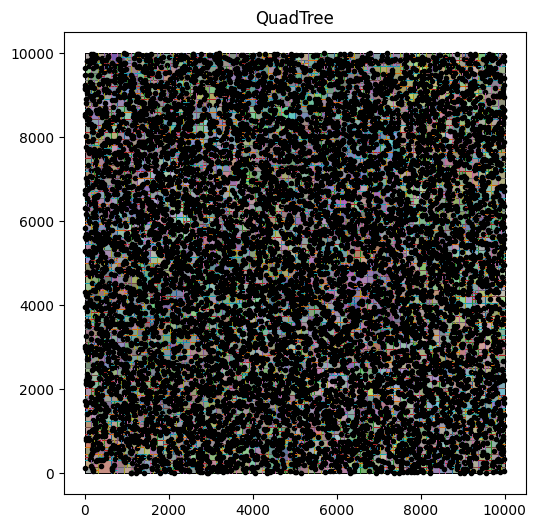

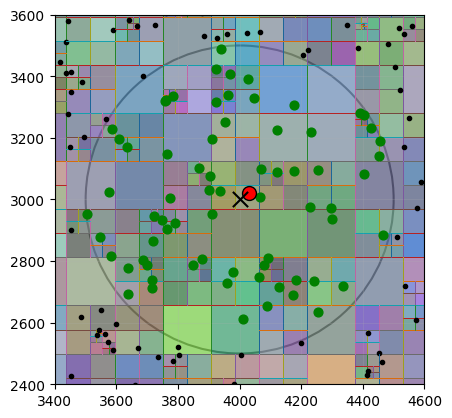

In [25]:
lista_coordenadas_tuples = [(coord["X"], coord["Y"]) for coord in lista_coordenadas]
objetivo = (4000,3000)
radio = 500
arbol = Quad_tree(lista_coordenadas_tuples)
cercano=arbol.buscar_cercano(arbol.raiz,objetivo)
print(cercano)
vecinos=arbol.buscar_en_radio(arbol.raiz,objetivo,radio)
print(vecinos)
fig, ax = plt.subplots(figsize=(6,6))

#grafica del quad_tree completo
graficar_Quad_tree(arbol.raiz,arbol.raiz.limite[0],arbol.raiz.limite[2],arbol.raiz.limite[1],arbol.raiz.limite[3],plt.gca())
ax.set_aspect('equal')
ax.set_title("QuadTree")

plt.show()

#grafica del quadtree centrado en la busqueda
graficar_busqueda(lista_coordenadas_tuples, objetivo, radio, vecinos, cercano, arbol)

###***codigo para las pruebas de Rendimiento***


In [26]:
def distancia(punto1, punto2):
    sum = 0
    for i in range(len(punto1)):
        sum += (punto1[i] - punto2[i]) ** 2
    sum = math.sqrt(sum)
    return sum
def fuerza_bruta(puntos, objetivo):
    mejor = None
    mejor_dist= float('inf')

    for p in puntos:
        d = distancia(p, objetivo)
        if d < mejor_dist:
            mejor = p
            mejor_dist = d

    return mejor

def radio_fb(puntos, obj, radio):
    vecinos = []
    for p in puntos:
        if distancia(p, obj) <= radio:
            vecinos.append(p)
    return vecinos

In [40]:
import time
import random
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def generar_puntos(n):
    return [(random.randint(0, 10000), random.randint(0,10000))for _ in range(n)]

def experimento(tamaño , obj):
    resultados = []
    objetivo = obj
    for n in tamaño:
        puntos = generar_puntos(n)
        promedio_tiempo_fb = 0
        promedio_tiempo_ca = 0
        promedio_tiempo_ab = 0
        for _ in range(50):
            #fuerza bruta
            t0 = time.time()
            fuerza_bruta(puntos, objetivo)
            t1 = time.time()

            tiempo_fb= t1 - t0
            promedio_tiempo_fb += tiempo_fb
        promedio_tiempo_fb= promedio_tiempo_fb/50

        for _ in range(50):
            #arbol-creacion
            t0 = time.time()
            arbol = Quad_tree(puntos)
            t1 = time.time()

            tiempo_ca= t1 - t0
            promedio_tiempo_ca += tiempo_ca
        promedio_tiempo_ca= promedio_tiempo_ca/50

        for _ in range(50):
            #arbol-busqueda
            t0 = time.time()
            arbol.buscar_cercano(arbol.raiz,objetivo)
            t1 = time.time()

            tiempo_ab= t1 - t0
            promedio_tiempo_ab += tiempo_ab
        promedio_tiempo_ab= promedio_tiempo_ab/50

        resultados.append((n, promedio_tiempo_fb, promedio_tiempo_ca, promedio_tiempo_ab , promedio_tiempo_ca + promedio_tiempo_ab))
    return resultados

def experimento_radio(tamaño , obj, radios):
    resultados = []
    objetivo = obj
    for n in tamaño:
        puntos = generar_puntos(n)

        for radio in radios:
            promedio_tiempo_fb = 0
            promedio_tiempo_ca = 0
            promedio_tiempo_ab = 0


            for _ in range(50):
                #arbol-creacion
                t0 = time.time()
                arbol = Quad_tree(puntos)
                t1 = time.time()

                tiempo_ca= t1 - t0
                promedio_tiempo_ca += tiempo_ca
            promedio_tiempo_ca= promedio_tiempo_ca/50

            for _ in range(50):
                #fuerza bruta
                t0 = time.time()
                radio_fb(puntos, objetivo, radio)
                t1 = time.time()

                tiempo_fb= t1 - t0
                promedio_tiempo_fb += tiempo_fb
            promedio_tiempo_fb= promedio_tiempo_fb/50


            for _ in range(50):
                #arbol-busqueda
                t0 = time.time()
                arbol.buscar_en_radio(arbol.raiz,objetivo,radio)
                t1 = time.time()

                tiempo_ab= t1 - t0
                promedio_tiempo_ab += tiempo_ab
            promedio_tiempo_ab= promedio_tiempo_ab/50

            resultados.append((n,radio, promedio_tiempo_fb, promedio_tiempo_ab))
    return resultados



#***prueba de rendimiento para encontrar al vecino mas cercano y grafica***

Para evaluar el desempeño del quad-tree en la búsqueda del vecino más cercano, se diseñó un experimento comparando este método con el enfoque de fuerza bruta.

Se generaron conjuntos de datos de distintos tamaños (n = 100, 2000, 4000, 6000, 8000, 10000), con puntos distribuidos aleatoriamente en el plano. Para cada conjunto, se definió un punto objetivo y se realizó la búsqueda del punto más cercano.

El experimento midió tres componentes principales en el caso del quad-tree:

el tiempo de construcción del árbol,
el tiempo de búsqueda del vecino más cercano,
y el tiempo total (suma de ambos).

Por otro lado, para el método de fuerza bruta, se midió el tiempo de búsqueda comparando el punto objetivo con todos los puntos del conjunto.

##**Resultados observados**

Los resultados muestran que:

El tiempo de búsqueda del quad-tree es muy bajo (del orden de 10^-5 a 10^-4 segundos en promedio), aunque puede variar dependiendo de la distribución de los puntos y la forma del árbol.
El tiempo de construcción del árbol crece con el tamaño del conjunto, debido a la subdivisión recursiva del espacio, alcanzando valores similares a los del árbol k-d para grandes cantidades de datos.
El tiempo total del quad-tree está dominado por el costo de construcción, lo que lo hace más lento que la fuerza bruta cuando solo se realiza una única consulta.

En contraste, el método de fuerza bruta presenta un crecimiento progresivo en el tiempo de ejecución, pasando de valores muy bajos en conjuntos pequeños (~10^-4 segundos) hasta aproximadamente 0.005 segundos en 10,000 puntos.

##**Conclusión**

A partir de los resultados, se concluye que:

Para los tamaños de datos analizados, el método de fuerza bruta puede resultar más eficiente que el quad-tree cuando se realiza una única búsqueda del vecino más cercano.

Esto se debe a que el costo de construcción del quad-tree es considerablemente mayor que el tiempo requerido por la fuerza bruta para recorrer todos los puntos.

Sin embargo, también se observa que:

El tiempo de búsqueda del quad-tree puede ser significativamente menor en promedio, especialmente cuando se aplica poda espacial durante la búsqueda. Esto lo convierte en una alternativa mucho más eficiente cuando se requieren múltiples consultas sobre el mismo conjunto de datos.

En estos casos, el costo de construcción del árbol se amortiza, y el rendimiento global del quad-tree puede superar al método de fuerza bruta.

(100, 4.713058471679688e-05, 0.0005257892608642579, 5.3501129150390626e-05, 0.0005792903900146485)
(2000, 0.0010603666305541992, 0.08165595531463624, 0.00016431331634521483, 0.08182026863098145)
(4000, 0.0020542478561401366, 0.04245584964752197, 0.0002285337448120117, 0.042684383392333984)
(6000, 0.003184056282043457, 0.15171083450317382, 0.00019866943359375, 0.15190950393676758)
(8000, 0.004023904800415039, 0.08088139057159424, 0.00023505210876464844, 0.08111644268035889)
(10000, 0.005588493347167969, 0.18274415016174317, 0.0002332925796508789, 0.18297744274139405)


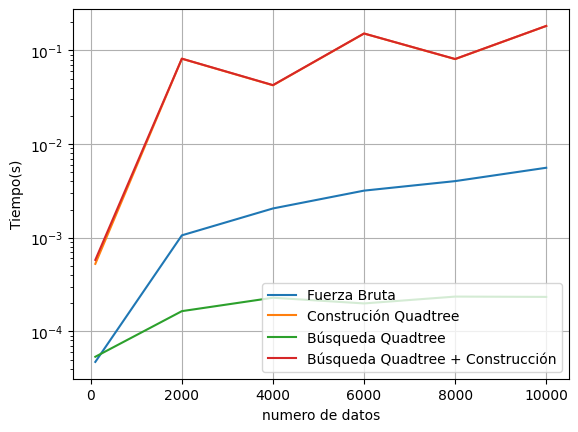

/tmp/ipykernel_5219/4064754504.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


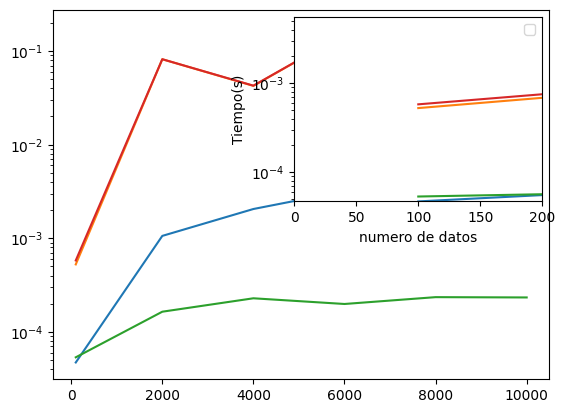

In [36]:
tamaño = [100,2000,4000,6000,8000,10000]
print("(n, promedio_tiempo_fb, promedio_tiempo_ca, promedio_tiempo_ab , promedio_tiempo_total)")
exp = experimento(tamaño,(5000,5000))
n = []
fb=[]
ac=[]
ab=[]
ca = []
for r in exp:
    n.append(r[0])
    fb.append(r[1])
    ac.append(r[2])
    ab.append(r[3])
    ca.append(r[4])
    print(r)

plt.plot(n, fb, label='Fuerza Bruta')
plt.plot(n, ac, label='Construción Quadtree')
plt.plot(n, ab, label='Búsqueda Quadtree')
plt.plot(n, ca, label='Búsqueda Quadtree + Construcción')

plt.xlabel('numero de datos')
plt.ylabel('Tiempo(s)')
plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(n, fb, label='Fuerza Bruta')
ax.plot(n, ac, label='Construción Quadtree')
ax.plot(n, ab, label='Búsqueda Quadtree')
ax.plot(n, ca, label='Búsqueda Quadtre + Construcción')



axins = inset_axes(ax, width="50%", height="50%")
loc= "upper right"
axins.plot(n,fb)
axins.plot(n,ac)
axins.plot(n,ab)
axins.plot(n,ca)

axins.set_xlim(0,200)
axins.set_ylim(min(fb),max(fb))
axins.set_xlabel('numero de datos')
axins.set_ylabel('Tiempo(s)')
axins.set_yscale("log")

ax.set_yscale("log")
plt.legend()
plt.show()

# ***Prueba de rendimiento con busqueda en radio y grafica***

Para evaluar el desempeño del QuadTree frente al método de fuerza bruta, se diseñó un experimento en el que se compararon los tiempos de ejecución de ambos enfoques en la búsqueda de puntos dentro de un radio dado.

Se generaron conjuntos de datos de tamaño n = 5000 y n = 10000, con puntos distribuidos aleatoriamente en el plano. Para cada conjunto, se definió un punto objetivo fijo y se realizaron consultas de búsqueda con distintos radios (r = 200, 400, 600, 800, 1000).

A diferencia del experimento anterior con el árbol k-d, en este caso solo se tuvo en cuenta el tiempo de búsqueda, tanto para el QuadTree como para el método de fuerza bruta.

Cada medición se repitió múltiples veces y se promediaron los resultados con el fin de reducir variaciones.

## **Resultados observados**

Los resultados obtenidos muestran que:

El tiempo de búsqueda del QuadTree es bajo y, en general, menor que el de fuerza bruta, especialmente para radios pequeños.
A medida que el radio de búsqueda aumenta, la diferencia de rendimiento entre ambos métodos disminuye.
En algunos casos, cuando el radio es grande, el QuadTree tiende a recorrer una mayor cantidad de nodos, acercándose al comportamiento de fuerza bruta.
El método de fuerza bruta mantiene un tiempo de ejecución más estable, ya que siempre recorre todos los puntos.

##**Conclusión**

A partir de los resultados, se concluye que:

El QuadTree es más eficiente que la fuerza bruta en la búsqueda por radio, especialmente cuando el radio es pequeño o cuando la región de búsqueda abarca una porción limitada del espacio.

Esto se debe a que el QuadTree permite descartar regiones completas del espacio (poda espacial), evitando revisar todos los puntos.

Sin embargo, también se observa que:

Cuando el radio de búsqueda es grande, el beneficio del QuadTree disminuye, ya que se incrementa la cantidad de nodos que deben explorarse, acercándose al comportamiento de fuerza bruta.

En general, el QuadTree resulta una mejor alternativa cuando se desea realizar búsquedas espaciales eficientes, especialmente en escenarios donde las consultas están localizadas y no abarcan todo el conjunto de datos.

In [43]:
tamaño_rad = [5000,10000]
radio = [200,400,600,800,1000]
print("(n,radio, promedio_tiempo_fb, promedio_tiempo_ab)")
exp_radio= experimento_radio(tamaño_rad,(5000,5000), radio)
for r in exp_radio:
    n.append(r[0])
    fb.append(r[2])
    ab.append(r[3])

    print(r)

import matplotlib.pyplot as plt

def graficar_resultados(resultados):
    # Obtener radios únicos
    radios = sorted(set(r[1] for r in resultados))

    for radio in radios:
        n_vals = []
        fb_vals = []
        kb_vals = []

        for r in resultados:
            if r[1] == radio:
                n_vals.append(r[0])
                fb_vals.append(r[2])
                kb_vals.append(r[3])

        plt.figure()
        plt.plot(n_vals, fb_vals, marker='o', label="Fuerza bruta")
        plt.plot(n_vals, kb_vals, marker='o', label="QuadTree")

        plt.title(f"Comparación para radio = {radio}")
        plt.xlabel("Número de puntos (n)")
        plt.ylabel("Tiempo (s)")
        plt.legend()
        plt.grid()

        plt.show()



(n,radio, promedio_tiempo_fb, promedio_tiempo_ab)
(5000, 200, 0.002997260093688965, 0.00010284900665283203)
(5000, 400, 0.002730302810668945, 0.00018373489379882812)
(5000, 600, 0.0027758121490478516, 0.00024391651153564452)
(5000, 800, 0.002645406723022461, 0.00047465324401855467)
(5000, 1000, 0.002659773826599121, 0.0006668853759765625)
(10000, 200, 0.005485386848449707, 0.00013631343841552735)
(10000, 400, 0.01050619125366211, 0.0005897426605224609)
(10000, 600, 0.00556643009185791, 0.0004652881622314453)
(10000, 800, 0.00614222526550293, 0.0008575725555419922)
(10000, 1000, 0.005341935157775879, 0.0012032604217529297)


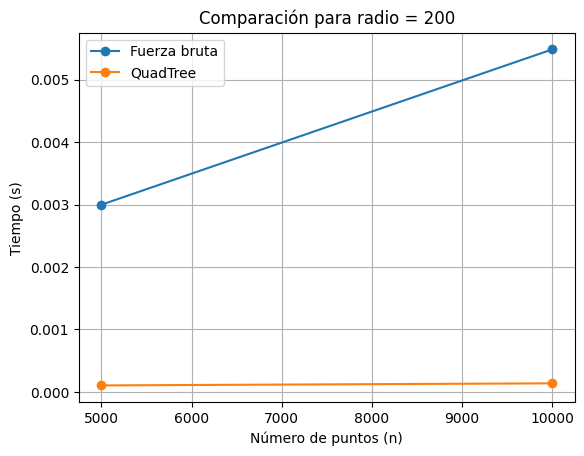

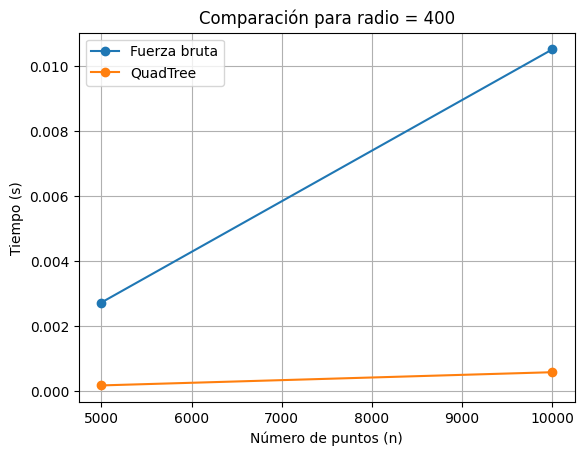

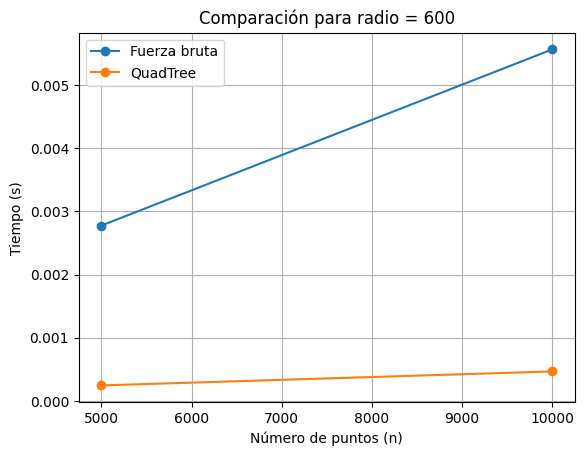

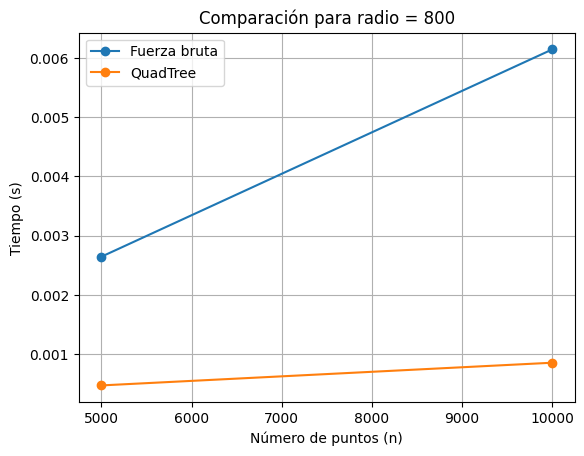

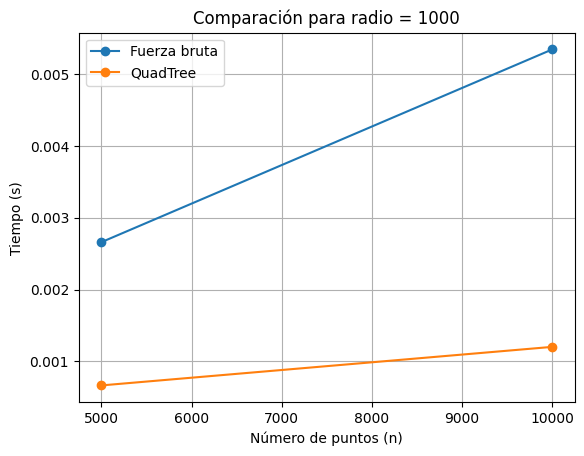

In [44]:
graficar_resultados(exp_radio)